In [16]:
!pip install wandb transformers sentencepiece peft -q
!pip uninstall -y hf_xet -q

import os, re, time, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter, defaultdict

warnings.filterwarnings('ignore')
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()
os.environ["WANDB_SILENT"] = "true"

# wandb login 
from kaggle_secrets import UserSecretsClient
import wandb
user_secrets = UserSecretsClient()
w_key = user_secrets.get_secret("WANDB_Key")
wandb.login(key=w_key)

# ---- ML / NLP libs ----
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding, set_seed)
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import string

# retry model download for network issues
def load_with_retry(load_fn, *args, retries=5, delay=8, **kwargs):
    for attempt in range(retries):
        try:
            return load_fn(*args, **kwargs)
        except Exception as e:
            if attempt == retries - 1:
                raise
            print(f"download failed (attempt {attempt+1}/{retries}), retrying in {delay}s...")
            time.sleep(delay)

OPTS   = ['A', 'B', 'C', 'D', 'E']
device = "cuda" if torch.cuda.is_available() else "cpu"

train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test  = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
sub   = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

print("train:", train.shape, "| test:", test.shape, "| device:", device)
train.head(3)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 55.0 MB/s eta 0:00:0000:0100:01
train: (2000, 8) | test: (500, 7) | device: cuda


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C


In [17]:
print("=== null counts ===")
print(train.isnull().sum())

print("\n=== answer distribution ===")
print(train['answer'].value_counts())

print("\n=== prompt length (words) ===")
print(train['prompt'].str.split().str.len().describe().round(2))

print("\n=== avg option length (words) ===")
for o in OPTS:
    print(f"  {o}: {train[o].str.split().str.len().mean():.1f}")

=== null counts ===
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

=== answer distribution ===
answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

=== prompt length (words) ===
count    2000.00
mean       18.15
std         6.78
min         3.00
25%        14.00
50%        17.00
75%        22.00
max        51.00
Name: prompt, dtype: float64

=== avg option length (words) ===
  A: 26.1
  B: 26.5
  C: 26.5
  D: 26.0
  E: 26.2


In [18]:
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize(text):
    return clean_text(text).split()

def remove_stopwords(tokens):
    return [t for t in tokens if t not in ENGLISH_STOP_WORDS and len(t) > 1]

for col in ['prompt'] + OPTS:
    train[f'clean_{col}'] = train[col].apply(clean_text)
    test[f'clean_{col}']  = test[col].apply(clean_text)

# vocab size of cleaned prompts
all_words = []
for p in train['clean_prompt']:
    all_words.extend(p.split())

print(f"unique vocab in cleaned prompts: {len(set(all_words))}")
print(f"sample — original : {train['prompt'].iloc[0]}")
print(f"sample — cleaned  : {train['clean_prompt'].iloc[0]}")

unique vocab in cleaned prompts: 859
sample — original : Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.
sample — cleaned  : pick the best possible answer what is martin heideggers view on the relationship between time and human existence among the listed options


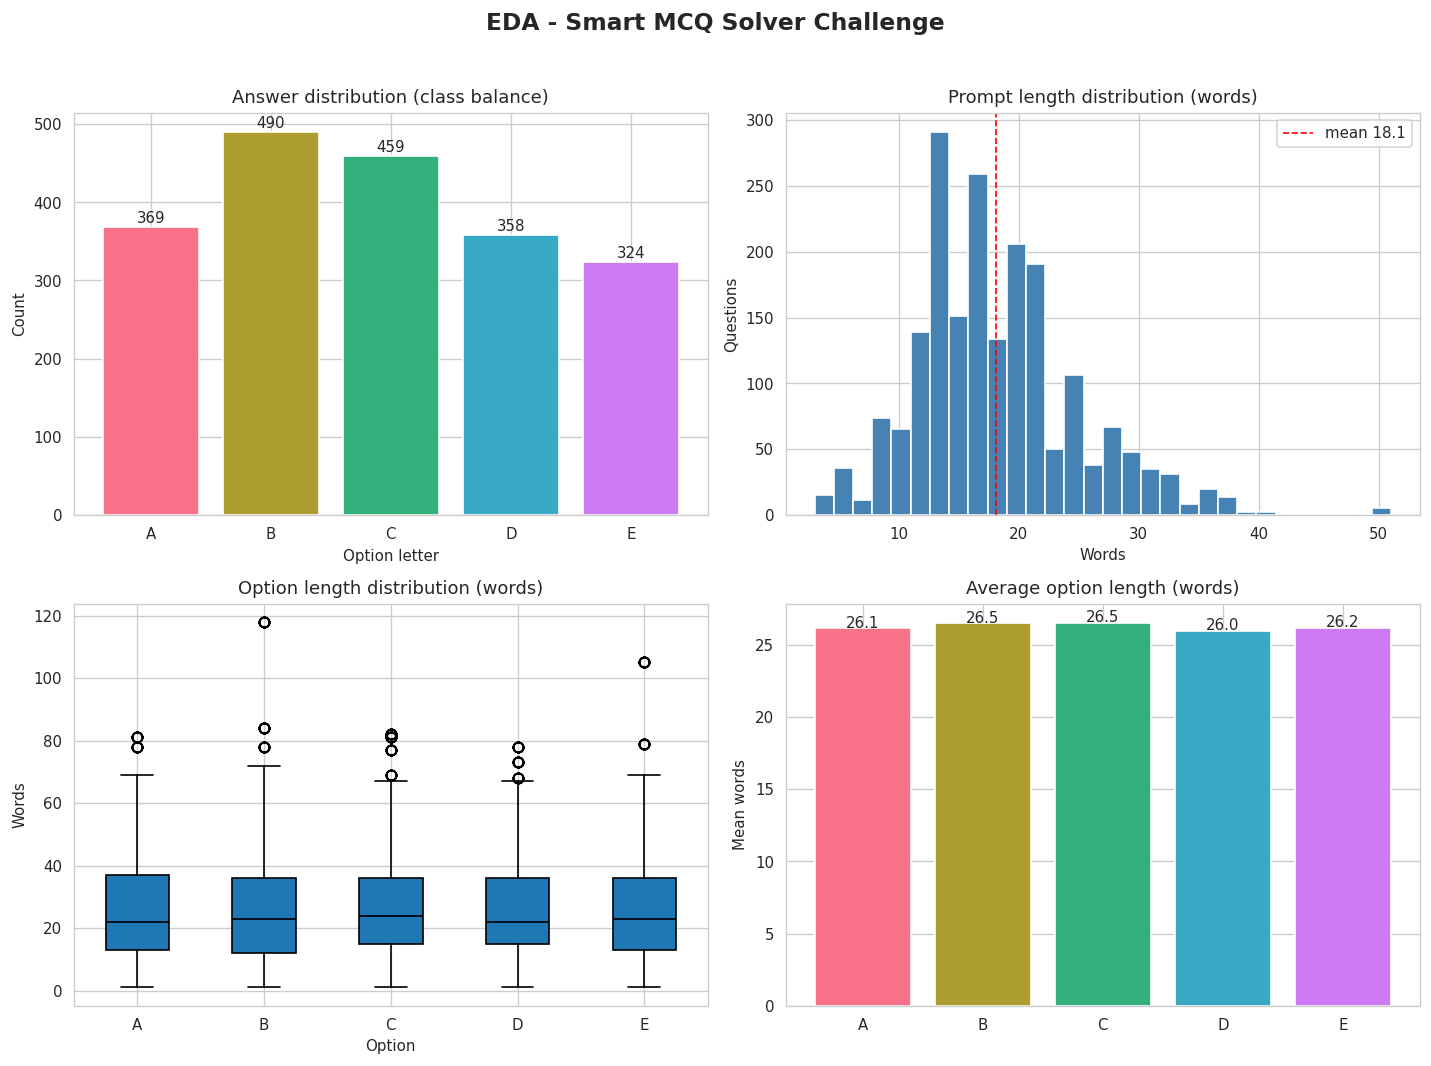


=== class balance summary ===
        count   pct
answer             
A         369  18.4
B         490  24.5
C         459  23.0
D         358  17.9
E         324  16.2

=== text length summary (words) ===
        prompt        A        B        C       D        E
count  2000.00  2000.00  2000.00  2000.00  2000.0  2000.00
mean     18.15    26.15    26.52    26.55    26.0    26.19
std       6.78    17.25    18.65    17.21    17.1    17.85
min       3.00     1.00     1.00     1.00     1.0     1.00
25%      14.00    13.00    12.00    14.75    15.0    13.00
50%      17.00    22.00    23.00    24.00    22.0    23.00
75%      22.00    37.00    36.00    36.00    36.0    36.00
max      51.00    81.00   118.00    82.00    78.0   105.00


In [19]:
plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("EDA - Smart MCQ Solver Challenge", fontsize=14, fontweight='bold')
colors = sns.color_palette("husl", 5)

# 1. class balance (bar chart with counts)
counts = train['answer'].value_counts().reindex(OPTS)
ax = axes[0, 0]
bars = ax.bar(counts.index, counts.values, color=colors)
ax.set_title("Answer distribution (class balance)")
ax.set_xlabel("Option letter"); ax.set_ylabel("Count")
for b, c in zip(bars, counts.values):
  ax.text(b.get_x() + b.get_width()/2, b.get_height() + 5, str(c),
          ha='center', fontsize=9)

# 2. prompt length distribution (histogram)
plen = train['prompt'].str.split().str.len()
ax = axes[0, 1]
ax.hist(plen, bins=30, color='steelblue', edgecolor='white')
ax.set_title("Prompt length distribution (words)")
ax.set_xlabel("Words"); ax.set_ylabel("Questions")
ax.axvline(plen.mean(), color='red', ls='--', lw=1, label=f"mean {plen.mean():.1f}")
ax.legend()

# 3. option length distribution (boxplot across A-E)
opt_len = pd.DataFrame({o: train[o].str.split().str.len() for o in OPTS})
ax = axes[1, 0]
ax.boxplot([opt_len[o].values for o in OPTS], labels=OPTS, patch_artist=True,
         medianprops=dict(color='black'))
ax.set_title("Option length distribution (words)")
ax.set_xlabel("Option"); ax.set_ylabel("Words")

# 4. average option length (bar chart)
avg_opt = train[OPTS].apply(lambda c: c.str.split().str.len().mean())
ax = axes[1, 1]
ax.bar(avg_opt.index, avg_opt.values, color=colors)
ax.set_title("Average option length (words)")
ax.set_ylabel("Mean words")
for i, v in enumerate(avg_opt.values):
  ax.text(i, v + 0.05, f"{v:.1f}", ha='center', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("/kaggle/working/eda_overview.png", bbox_inches='tight', dpi=150)
plt.show()

# printed stats tables for the report text
print("\n=== class balance summary ===")
print(train['answer'].value_counts().reindex(OPTS).to_frame('count').assign(
  pct=lambda d: (100 * d['count'] / d['count'].sum()).round(1)))
print("\n=== text length summary (words) ===")
print(pd.DataFrame({
  'prompt': plen.describe().round(2),
  **{o: train[o].str.split().str.len().describe().round(2) for o in OPTS}
}))

In [20]:
OPTS = list("ABCDE")
# convert option letters to ids and back
LETTER2ID = {o: i for i, o in enumerate(OPTS)}
ID2LETTER = {i: o for o, i in LETTER2ID.items()}

def format_mcq(row):
    # combine question and all options into one text
    return (f"{row['prompt']} "
            f"A) {row['A']} B) {row['B']} C) {row['C']} D) {row['D']} E) {row['E']}")

def clean_text(t):
    # lowercase and remove special characters
    return re.sub(r"[^a-z0-9\s]", " ", str(t).lower())

# average precision for one sample
def apk(actual, predicted, k=3):
    for i, p in enumerate(predicted[:k]):
        if p == actual:
            return 1.0 / (i + 1)
    return 0.0

# mean average precision over all samples
def mapk(actuals, predictions, k=3):
    return sum(apk(a, p, k) for a, p in zip(actuals, predictions)) / len(actuals)

def top1_accuracy(actuals, predictions):
    return round(accuracy_score(actuals, [p[0] for p in predictions]), 4)

def top1_f1(actuals, predictions):
    return round(f1_score(actuals, [p[0] for p in predictions], average='macro'), 4)

actuals = train['answer'].tolist()

# use gpu if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

def load_with_retry(fn, *args, retries=3, **kwargs):
    # retry loading if temporary error happens
    for i in range(retries):
        try:
            return fn(*args, **kwargs)
        except Exception as e:
            if i == retries - 1:
                raise
            print(f"  retry {i+1}/{retries}: {e}")

SEED = 42

def seed_everything(seed):
    # same seed gives same results
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    set_seed(seed)

train_inputs = [format_mcq(row) for _, row in train.iterrows()]
train_labels = [LETTER2ID[a] for a in train['answer']]

# split text into words
def toks(t):
    return re.findall(r"[a-z0-9]+", t.lower())
# special tokens
vocab = {"<pad>": 0, "<unk>": 1}

# build vocabulary from training data
for _, r in train.iterrows():
    for w in toks(format_mcq(r)):
        if w not in vocab:
            vocab[w] = len(vocab)

MAXL = 64  # maximum sequence length

def enc(t):
    # convert words to ids
    ids = [vocab.get(w, 1) for w in toks(t)[:MAXL]]
    # pad shorter sequences with zeros
    return ids + [0] * (MAXL - len(ids))

cnn_X = np.array([enc(format_mcq(r)) for _, r in train.iterrows()])
cnn_y = np.array([LETTER2ID[a] for a in train['answer']])

# keep class ratio same in train and validation
cnn_Xtr, cnn_Xva, cnn_ytr, cnn_yva = train_test_split(
    cnn_X,
    cnn_y,
    test_size=0.1,
    stratify=cnn_y,
    random_state=42
)

cnn_ytr_l = [ID2LETTER[i] for i in cnn_ytr]
cnn_yva_l = [ID2LETTER[i] for i in cnn_yva]

def train_one(model, epochs=40, bs=64, lr=1e-3, seed=42):
    torch.manual_seed(seed)

    # adam optimizer
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.CrossEntropyLoss()

    n = len(cnn_Xtr)

    for ep in range(epochs):
        model.train()

        # shuffle training samples
        perm = np.random.permutation(n)
        tot = 0.0

        for i in range(0, n, bs):
            idx = perm[i:i + bs]

            opt.zero_grad()

            loss = lossf(
                model(torch.tensor(cnn_Xtr[idx]).to(device)),
                torch.tensor(cnn_ytr[idx]).to(device)
            )

            loss.backward()  # compute gradients
            opt.step()       # update weights

            tot += loss.item() * len(idx)

        # print loss every 10 epochs
        if (ep + 1) % 10 == 0:
            print(f"  ep{ep+1} loss {tot/n:.3f}")

            # save loss to wandb
            if wandb.run is not None:
                wandb.log({"loss": tot / n}, step=ep)

def evaluate(model, Xe, ye_l, name):
    model.eval()

    # no gradients needed during evaluation
    with torch.no_grad():
        lg = model(torch.tensor(Xe).to(device)).cpu().numpy()

    # top 3 predicted options
    preds = [[ID2LETTER[i] for i in np.argsort(-lg[k])[:3]] for k in range(len(Xe))]

    m3, acc = mapk(ye_l, preds), top1_accuracy(ye_l, preds)

    print(f"{name}: MAP@3 {m3:.4f}  acc {acc:.4f}")
    return m3, acc

print("Utility Functions ready - vocab:", len(vocab), "| train:", len(cnn_Xtr), "val:", len(cnn_Xva))

device: cuda
Utility Functions ready - vocab: 2975 | train: 1800 val: 200


In [21]:
# model 1 : tf-idf + logistic regression

full_corpus = []
# collect all question and option text
for df in [train, test]:
    for _, row in df.iterrows():
        full_corpus.append(row['prompt'])
        for o in OPTS:
            full_corpus.append(row[o])

# word level tf-idf
word_tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),   # use unigrams and bigrams
    max_features=25000,
    sublinear_tf=True
)

# character level tf-idf
char_tfidf = TfidfVectorizer(
    analyzer='char_wb',   # character ngrams inside word boundaries
    ngram_range=(3, 5),
    max_features=15000,
    sublinear_tf=True
)

# build vocabulary from full corpus
word_tfidf.fit(full_corpus)
char_tfidf.fit(full_corpus)

print(f"word tfidf vocab: {len(word_tfidf.vocabulary_)} | char tfidf vocab: {len(char_tfidf.vocabulary_)}")

def build_row_features(row):
    # tf-idf vectors for the question
    p_word = word_tfidf.transform([row['prompt']])
    p_char = char_tfidf.transform([row['prompt']])
    feats = []
    for o in OPTS:
        o_word = word_tfidf.transform([row[o]])
        o_char = char_tfidf.transform([row[o]])
        # word similarity
        feats.append(cosine_similarity(p_word, o_word)[0][0])
        # character similarity
        feats.append(cosine_similarity(p_char, o_char)[0][0])
        # option length compared to question
        feats.append(len(row[o].split()) / max(len(row['prompt'].split()), 1))
        # token overlap score
        p_tok = set(clean_text(row['prompt']).split())
        o_tok = set(clean_text(row[o]).split())
        feats.append(len(p_tok & o_tok) / max(len(p_tok | o_tok), 1))
    return feats

print("building features for all train rows...")

X = np.array([build_row_features(row) for _, row in train.iterrows()])
y = train['answer'].map(LETTER2ID).values

# out-of-fold predictions for fair evaluation
oof_probs = np.zeros((len(train), 5))

# stratified split keeps class balance
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
    clf = LogisticRegression(
        max_iter=2000,   # allow more iterations to converge
        C=2.0,
        random_state=42
    )
    clf.fit(X[tr_idx], y[tr_idx])
    oof_probs[va_idx] = clf.predict_proba(X[va_idx])
    print(f"fold {fold+1}/5 done")

# train final model on full training data
tfidf_clf = LogisticRegression(max_iter=2000, C=2.0, random_state=42)
tfidf_clf.fit(X, y)

def rank_tfidf(row):
    probs = tfidf_clf.predict_proba(
        np.array(build_row_features(row)).reshape(1, -1)
    )[0]
    scores = {ID2LETTER[i]: probs[i] for i in range(5)}
    # return options sorted by probability
    return sorted(scores, key=lambda x: scores[x], reverse=True)

# top 3 predictions from oof probabilities
oof_ranked = [[ID2LETTER[i] for i in np.argsort(-p)[:3]] for p in oof_probs]
map3_tfidf = round(mapk(actuals, oof_ranked), 4)
acc_tfidf  = top1_accuracy(actuals, oof_ranked)
f1_tfidf   = top1_f1(actuals, oof_ranked)

print(f"\ntfidf (5-fold OOF)  MAP@3 : {map3_tfidf} | acc: {acc_tfidf}, f1: {f1_tfidf}")

# log metrics to wandb
run = wandb.init(
    project="23f1000362-t22026",
    name="model1-tfidf-supervised",
    config={
        "features": "word+char tfidf cosine, len_ratio, jaccard",
        "cv": "5fold_oof",
        "C": 2.0
    },
    tags=["milestone-5", "from-scratch", "tfidf"]
)
wandb.log({
    "map3": map3_tfidf,
    "accuracy": acc_tfidf,
    "f1": f1_tfidf
})
wandb.finish()

print("Model 1 complete - tfidf trained; tfidf_clf + build_row_features + rank_tfidf ready")

word tfidf vocab: 10915 | char tfidf vocab: 15000
building features for all train rows...
fold 1/5 done
fold 2/5 done
fold 3/5 done
fold 4/5 done
fold 5/5 done

tfidf (5-fold OOF)  MAP@3 : 0.6378 | acc: 0.4855, f1: 0.4809
Model 1 complete - tfidf trained; tfidf_clf + build_row_features + rank_tfidf ready


Uses word and character TF-IDF features with handcrafted similarity features.
Logistic Regression predicts the most likely answer option.

In [22]:
cls_tok = load_with_retry(AutoTokenizer.from_pretrained, "roberta-base")
cls_base = load_with_retry(
    AutoModelForSequenceClassification.from_pretrained,
    "roberta-base",
    num_labels=5  # five output classes
)
# tokenize training data
cls_enc = cls_tok(train_inputs, truncation=True, max_length=256, padding=False)
cls_enc['labels'] = train_labels
hf_cls = Dataset.from_dict(cls_enc)

# keep some data for validation
_split = hf_cls.train_test_split(test_size=0.1, seed=42)
hf_cls_train, hf_cls_val = _split['train'], _split['test']
print(f"train: {len(hf_cls_train)}  val: {len(hf_cls_val)}")

# set random seeds
seed_everything(SEED)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

# lora settings
lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    target_modules=["query", "value"],  # apply lora here
    lora_dropout=0.1,
    bias="none"
)
lora_model = get_peft_model(cls_base, lora_cfg).to(device)
lora_model.print_trainable_parameters()

# pad batches automatically
cls_collator = DataCollatorWithPadding(cls_tok)

cls_args = TrainingArguments(
    output_dir="/kaggle/working/lora_cls",
    num_train_epochs=6,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=2,  # bigger effective batch
    learning_rate=2e-4,
    warmup_steps=50,
    fp16=False,
    logging_steps=25,
    eval_strategy="epoch",  # validate after every epoch
    save_strategy="no",
    report_to="wandb",
    dataloader_pin_memory=False,
    dataloader_num_workers=0,
    seed=SEED,
    data_seed=SEED
)

wandb.init(
    project="23f1000362-t22026",
    name="model4-lora-roberta",
    config={
        "lora_r": 16,
        "lora_alpha": 32,
        "lr": 2e-4,
        "epochs": 6,
        "seed": SEED,
        "max_length": 256,
        "fp16": False,
        "deterministic": True,
        "eval": "90/10 split"
    },
    tags=["milestone-5", "lora", "roberta"]
)
cls_trainer = Trainer(
    model=lora_model,
    args=cls_args,
    train_dataset=hf_cls_train,
    eval_dataset=hf_cls_val,
    data_collator=cls_collator,
    processing_class=cls_tok
)

print("starting lora roberta finetuning...")
cls_trainer.train()
# switch to eval mode
lora_model.eval()

def get_lora_logits(model, row):
    inputs = cls_tok(
        format_mcq(row),
        return_tensors="pt",
        truncation=True,
        max_length=256
    ).to(device)
    with torch.no_grad():
        return model(**inputs).logits[0].cpu().numpy()

def rank_lora(row):
    logits = get_lora_logits(lora_model, row)
    scores = {ID2LETTER[i]: logits[i] for i in range(5)}
    # sort by prediction score
    return sorted(scores, key=lambda x: scores[x], reverse=True)

# get top 3 predictions
lora_preds = [rank_lora(row)[:3] for _, row in train.iterrows()]
map3_lora = round(mapk(actuals, lora_preds), 4)
acc_lora = top1_accuracy(actuals, lora_preds)
f1_lora = top1_f1(actuals, lora_preds)

print(f"roberta lora  MAP@3 : {map3_lora} | acc: {acc_lora}, f1: {f1_lora}")

# log final metrics
wandb.log({
    "map3": map3_lora,
    "accuracy": acc_lora,
    "f1": f1_lora
})
wandb.finish()
print("Model 2 complete - roberta lora trained; lora_model + rank_lora ready")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

train: 1800  val: 200
trainable params: 1,184,261 || all params: 125,833,738 || trainable%: 0.9411
starting lora roberta finetuning...
{'loss': '6.425', 'grad_norm': '5.84', 'learning_rate': '9.6e-05', 'epoch': '0.8772'}
{'eval_loss': '3.189', 'eval_runtime': '2.094', 'eval_samples_per_second': '95.53', 'eval_steps_per_second': '6.209', 'epoch': '1'}
{'loss': '6.272', 'grad_norm': '2.63', 'learning_rate': '0.000196', 'epoch': '1.737'}
{'eval_loss': '3.097', 'eval_runtime': '2.045', 'eval_samples_per_second': '97.81', 'eval_steps_per_second': '6.358', 'epoch': '2'}
{'loss': '5.792', 'grad_norm': '6.893', 'learning_rate': '0.0001613', 'epoch': '2.596'}
{'eval_loss': '2.183', 'eval_runtime': '2.093', 'eval_samples_per_second': '95.56', 'eval_steps_per_second': '6.211', 'epoch': '3'}
{'loss': '4.337', 'grad_norm': '9.519', 'learning_rate': '0.000121', 'epoch': '3.456'}
{'eval_loss': '1.483', 'eval_runtime': '2.065', 'eval_samples_per_second': '96.87', 'eval_steps_per_second': '6.297', 'epo

Fine-tunes RoBERTa using LoRA for efficient training with fewer trainable parameters.
The model directly predicts one of the five answer classes.

In [ ]:
deberta_tok  = load_with_retry(AutoTokenizer.from_pretrained, "microsoft/deberta-v3-base")
deberta_base = load_with_retry(AutoModelForSequenceClassification.from_pretrained,
                               "microsoft/deberta-v3-base", num_labels=5)  # 5 output classes

# tokenize all training data
deberta_enc = deberta_tok(train_inputs, truncation=True, max_length=256, padding=False)
deberta_enc['labels'] = train_labels
hf_deberta = Dataset.from_dict(deberta_enc)

# split into train and validation
_split = hf_deberta.train_test_split(test_size=0.1, seed=42)
hf_deberta_train, hf_deberta_val = _split['train'], _split['test']
print(f"train: {len(hf_deberta_train)}  val: {len(hf_deberta_val)}")

# lora configuration
lora_cfg_deberta = LoraConfig(task_type=TaskType.SEQ_CLS, r=16, lora_alpha=32,
                              target_modules=["query_proj", "value_proj"],  # attention layers
                              lora_dropout=0.1, bias="none")
lora_deberta = get_peft_model(deberta_base, lora_cfg_deberta).to(device)
lora_deberta.print_trainable_parameters()

# dynamic padding
deberta_collator = DataCollatorWithPadding(deberta_tok)
args_deberta = TrainingArguments(
    output_dir="/kaggle/working/lora_deberta", num_train_epochs=6,
    per_device_train_batch_size=16, gradient_accumulation_steps=2,  # bigger effective batch
    learning_rate=2e-4, warmup_steps=50,
    fp16=False, logging_steps=25,
    eval_strategy="epoch",  # evaluate every epoch
    save_strategy="no", report_to="wandb",
    dataloader_pin_memory=False, dataloader_num_workers=0, seed=42
)

# start wandb run
wandb.init(project="23f1000362-t22026", name="model5-lora-deberta",
           config={"lora_r": 16, "lora_alpha": 32, "lr": 2e-4, "epochs": 6,
                   "base_model": "microsoft/deberta-v3-base", "eval": "90/10 split"},
           tags=["milestone-5", "lora", "deberta"])

trainer_deberta = Trainer(model=lora_deberta, args=args_deberta,
                          train_dataset=hf_deberta_train, eval_dataset=hf_deberta_val,
                          data_collator=deberta_collator, processing_class=deberta_tok)

print("starting lora deberta finetuning...")
trainer_deberta.train()

# switch to eval mode
lora_deberta.eval()

def get_deberta_logits(row):
    inputs = deberta_tok(format_mcq(row), return_tensors="pt",
                         truncation=True, max_length=256).to(device)
    # inference only
    with torch.no_grad():
        return lora_deberta(**inputs).logits[0].cpu().numpy()

def rank_lora_deberta(row):
    logits = get_deberta_logits(row)
    scores = {ID2LETTER[i]: logits[i] for i in range(5)}
    # sort by score
    return sorted(scores, key=lambda x: scores[x], reverse=True)

# top 3 predictions
deberta_preds = [rank_lora_deberta(row)[:3] for _, row in train.iterrows()]
map3_deberta = round(mapk(actuals, deberta_preds), 4)
acc_deberta  = top1_accuracy(actuals, deberta_preds)
f1_deberta   = top1_f1(actuals, deberta_preds)
print(f"deberta lora  MAP@3 : {map3_deberta} | acc: {acc_deberta}, f1: {f1_deberta}")

# log metrics
wandb.log({"map3": map3_deberta, "accuracy": acc_deberta, "f1": f1_deberta})
wandb.finish()
print("Model 3 complete - deberta lora trained; rank_lora_deberta + get_deberta_logits ready")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

train: 1800  val: 200
trainable params: 593,669 || all params: 185,019,658 || trainable%: 0.3209
starting lora deberta finetuning...
{'loss': '6.516', 'grad_norm': '6.599', 'learning_rate': '9.6e-05', 'epoch': '0.8772'}
{'eval_loss': '3.205', 'eval_runtime': '1.507', 'eval_samples_per_second': '132.7', 'eval_steps_per_second': '8.627', 'epoch': '1'}


Uses DeBERTa-v3 with LoRA for parameter-efficient fine-tuning.
Designed to capture stronger contextual relationships between the question and options.

In [ ]:
class TextCNN(nn.Module):
    def __init__(self, V, D=100, C=128, kernels=(3, 4, 5)):
        super().__init__()
        self.emb = nn.Embedding(V, D, padding_idx=0)
        # different kernel sizes capture different n-grams
        self.convs = nn.ModuleList([nn.Conv1d(D, C, k, padding=k // 2) for k in kernels])
        self.drop = nn.Dropout(0.4)
        self.fc = nn.Linear(C * len(kernels), 5)

    def forward(self, x):
        # embedding output -> conv1d format
        e = self.emb(x).transpose(1, 2)                    # B,D,L

        # max pooling after each convolution
        pooled = [F.relu(conv(e)).max(dim=2).values for conv in self.convs]  # B,C each

        # combine all features
        return self.fc(self.drop(torch.cat(pooled, dim=1)))

cnn_model = TextCNN(len(vocab)).to(device)
# total model parameters
print("TextCNN params:", sum(p.numel() for p in cnn_model.parameters()))
train_one(cnn_model)

# evaluate on train and validation
m3_cnn_tr, acc_cnn_tr = evaluate(cnn_model, cnn_Xtr, cnn_ytr_l, "TextCNN train")
m3_cnn_va, acc_cnn_va = evaluate(cnn_model, cnn_Xva, cnn_yva_l, "TextCNN val  ")

run = wandb.init(project="23f1000362-t22026", name="model6-textcnn-custom-dl",
                 config={"arch": "TextCNN", "kernels": [3, 4, 5], "channels": 128,
                         "emb": 100, "epochs": 40, "lr": 1e-3},
                 tags=["milestone-5", "custom-dl", "textcnn"])
# save train and val metrics
wandb.log({"map3_train": m3_cnn_tr, "map3_val": m3_cnn_va,
           "acc_train": acc_cnn_tr, "acc_val": acc_cnn_va})
wandb.finish()
print("Model 4 complete - TextCNN trained; cnn_model ready for ensemble")

A custom CNN model that learns local text patterns using multiple convolution kernel sizes.
Max pooling combines the most important features for classification.

In [ ]:
class BiLSTMAttn(nn.Module):
    def __init__(self, V, D=100, H=64):
        super().__init__()
        self.emb = nn.Embedding(V, D, padding_idx=0)
        # bidirectional lstm
        self.lstm = nn.LSTM(D, H, batch_first=True, bidirectional=True)
        self.attn = nn.Linear(2 * H, 1)          # attention score for each token
        self.drop = nn.Dropout(0.3)
        self.fc = nn.Linear(2 * H, 5)

    def forward(self, x):
        out, _ = self.lstm(self.emb(x))          # B,L,2H
        # calculate attention scores
        scores = self.attn(out).squeeze(-1)      # B,L
        # ignore padding tokens
        scores = scores.masked_fill(x == 0, float("-inf"))
        # attention weights
        w = torch.softmax(scores, dim=1).unsqueeze(-1)       # B,L,1
        # weighted sum of all outputs
        v = (out * w).sum(dim=1)                 # B,2H
        return self.fc(self.drop(v))

rnn_model = BiLSTMAttn(len(vocab)).to(device)

# total model parameters
print("BiLSTM params:", sum(p.numel() for p in rnn_model.parameters()))

train_one(rnn_model)
# evaluate on train and validation
m3_rnn_tr, acc_rnn_tr = evaluate(rnn_model, cnn_Xtr, cnn_ytr_l, "BiLSTM train")
m3_rnn_va, acc_rnn_va = evaluate(rnn_model, cnn_Xva, cnn_yva_l, "BiLSTM val  ")

run = wandb.init(project="23f1000362-t22026", name="model7-bilstm-rnn",
                 config={"arch": "BiLSTM+attention", "hidden": 64, "emb": 100,
                         "epochs": 40, "lr": 1e-3},
                 tags=["milestone-5", "rnn", "bilstm"])
wandb.log({"map3_train": m3_rnn_tr, "map3_val": m3_rnn_va,
           "acc_train": acc_rnn_tr, "acc_val": acc_rnn_va})

wandb.finish()
print("Model 5 complete - BiLSTM trained; rnn_model ready for ensemble")

A bidirectional LSTM processes the sequence from both directions.
The attention layer focuses on the most relevant words before prediction.

In [ ]:
import numpy as np

def softmax(v):
    v = np.asarray(v, dtype=float)
    v = v - v.max()
    e = np.exp(v)
    return e / e.sum()

# comparison table 
rows = []
if 'map3_tfidf' in globals():
    rows.append(["TF-IDF + LogReg", map3_tfidf, acc_tfidf, "20 features", "5-fold OOF"])
if 'map3_lora' in globals():
    np_ro = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
    rows.append(["RoBERTa-LoRA", map3_lora, acc_lora, f"{np_ro:,}", "train (2000)"])
if 'map3_deberta' in globals():
    np_db = sum(p.numel() for p in lora_deberta.parameters() if p.requires_grad)
    rows.append(["DeBERTa-v3-LoRA", map3_deberta, acc_deberta, f"{np_db:,}", "train (2000)"])
if 'm3_cnn_va' in globals():
    np_cn = sum(p.numel() for p in cnn_model.parameters())
    rows.append(["TextCNN (custom)", f"{m3_cnn_tr:.4f}/{m3_cnn_va:.4f}",
                 f"{acc_cnn_tr:.4f}/{acc_cnn_va:.4f}", f"{np_cn:,}", "train/val split"])
if 'm3_rnn_va' in globals():
    np_rn = sum(p.numel() for p in rnn_model.parameters())
    rows.append(["BiLSTM+attn (RNN)", f"{m3_rnn_tr:.4f}/{m3_rnn_va:.4f}",
                 f"{acc_rnn_tr:.4f}/{acc_rnn_va:.4f}", f"{np_rn:,}", "train/val split"])

table = pd.DataFrame(rows, columns=["Model", "MAP@3", "Accuracy", "Params", "Eval basis"])
print("=== model comparison ===")
print(table.to_string(index=False))
print("\n(MAP@3/Accuracy shown as train/val where a val split exists)")

# weighted-probability ensemble
HAS = {
    "roberta": 'lora_model' in globals() and 'get_lora_logits' in globals(),
    "deberta": 'lora_deberta' in globals() and 'get_deberta_logits' in globals(),
    "cnn":     'cnn_model' in globals(),
    "bilstm":  'rnn_model' in globals(),
    "tfidf":   'tfidf_clf' in globals(),
}
# weights: roberta dominates (strongest single)
W = {"roberta": 0.50, "deberta": 0.15, "cnn": 0.12, "bilstm": 0.13, "tfidf": 0.10}
W = {k: v for k, v in W.items() if HAS[k]}
s = sum(W.values())
W = {k: v / s for k, v in W.items()}
print("\nensemble models:", list(W.keys()), "| weights:", {k: round(v, 3) for k, v in W.items()})

def probs_cnn_like(model, row):
    x = torch.tensor(enc(format_mcq(row))).unsqueeze(0).to(device)
    with torch.no_grad():
        return softmax(model(x).cpu().numpy()[0])

test_preds = []
for _, row in test.iterrows():
    p = np.zeros(5)
    if 'roberta' in W:
        p += W["roberta"] * softmax(get_lora_logits(lora_model, row))
    if 'deberta' in W:
        p += W["deberta"] * softmax(get_deberta_logits(row))
    if 'cnn' in W:
        p += W["cnn"] * probs_cnn_like(cnn_model, row)
    if 'bilstm' in W:
        p += W["bilstm"] * probs_cnn_like(rnn_model, row)
    if 'tfidf' in W:
        p += W["tfidf"] * tfidf_clf.predict_proba(
            np.array(build_row_features(row)).reshape(1, -1))[0]
    order = np.argsort(-p)[:3]
    test_preds.append(" ".join(ID2LETTER[i] for i in order))

submission = pd.DataFrame({'ID': test['id'].values, 'Prediction': test_preds})
submission.to_csv("submission.csv", index=False)
print("\nsubmission head:")
print(submission.head(10))
print("shape:", submission.shape)
assert submission['Prediction'].str.split().apply(len).eq(3).all()
assert list(submission.columns) == ['ID', 'Prediction']
print("OK: 3 letters per row, columns correct.")